In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from uncertainties import unumpy as unp

from utils.fit import Fit
from utils.helpers import (
    get_efficiency,
    get_migration_matrix,
    get_values,
    plot_efficiency,
    plot_migration_matrix,
    plot_values,
    setup_plot_style,
)

In [3]:
setup_plot_style()

# Main


In [4]:
# create dummy variables to unfold `x_reco` to `x_truth`
size = 1_000_000
num_bins = 8
bin_lims = (0, 8)
edges = np.linspace(*bin_lims, num_bins + 1)
reco_var = "x_reco"
truth_var = "x_truth"
truth_label = r"$x_{\mathsf{truth}}$"
reco_label = r"$x_{\mathsf{reco}}$"
reco_query = "is_reco == True"

x_truth = np.random.normal(loc=4.0, scale=1.0, size=size)
x_reco = x_truth + np.random.normal(loc=0.5, scale=0.5, size=size)
# x-dependet efficiency: quadratically decreasing from 1.0 at 0 and 0.8 at 8.0
_eff = 0.2 * (x_reco / bin_lims[1]) ** 2
is_reco = np.random.uniform(size=size) > _eff
toy_df = pd.DataFrame({truth_var: x_truth, reco_var: x_reco, "is_reco": is_reco})
# select events with reco and true values within bin limits
toy_df = toy_df.query(
    f"({truth_var} > {bin_lims[0]}) & ({truth_var} < {bin_lims[1]})"
    f" & ({reco_var} > {bin_lims[0]}) & ({reco_var} < {bin_lims[1]})"
)
display(toy_df.head())

,x_truth,x_reco,is_reco
0,3.595261,3.795690,True
1,4.035213,4.068888,True
2,4.361774,3.780226,True
3,4.425777,5.088720,True
4,3.040992,3.255228,True


In [5]:
reco_values = get_values(toy_df, var=reco_var, edges=edges, query=reco_query)
truth_values = get_values(toy_df, var=truth_var, edges=edges)
eff = get_efficiency(df=toy_df, var=truth_var, edges=edges, query=reco_query)
mig = get_migration_matrix(
    df=toy_df,
    truth_var=truth_var,
    reco_var=reco_var,
    query=reco_query,
    edges=edges,
)

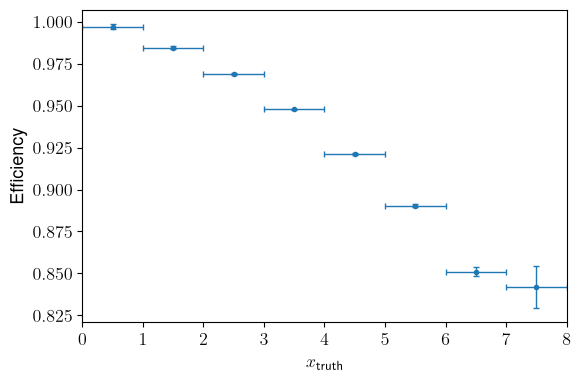

In [6]:
plot_efficiency(eff, edges=edges, xlabel=truth_label)

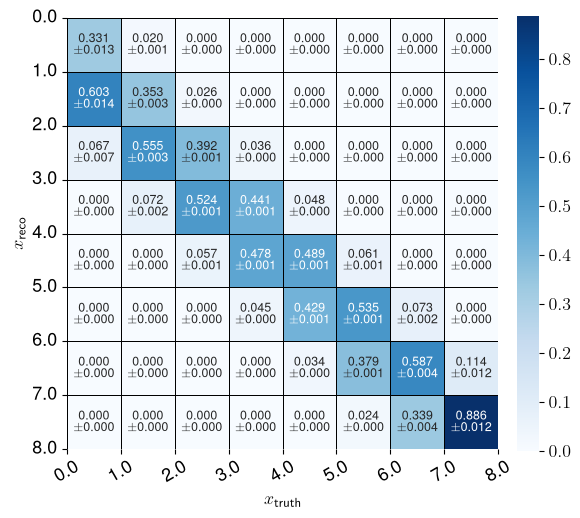

In [7]:
plot_migration_matrix(
    mig,
    xlabel=truth_label,
    ylabel=reco_label,
    xedges=edges,
    yedges=edges,
)

In [8]:
initial_guess = {
    "mu": unp.nominal_values(truth_values)
    * np.random.normal(loc=1.0, scale=0.1, size=num_bins),
}
initial_guess.update({f"theta_mig_{i}": 1e-3 for i in range(num_bins * num_bins)})
initial_guess.update({f"theta_eff_{i}": 1e-3 for i in range(num_bins)})

In [9]:
fit = Fit(
    meas=unp.nominal_values(reco_values),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mig),
    mig_unc=unp.std_devs(mig),
    eff=unp.nominal_values(eff),
    eff_unc=unp.std_devs(eff),
)

In [10]:
print("pre fit values")
print(", ".join([f"{i:.1f}" for i in reco_values]))

print("truth values")
print(", ".join([f"{i:.1f}" for i in truth_values]))

print("post fit values")
fit_values = fit.signal_muarray
print(", ".join([f"{i:.1f}" for i in fit_values]))

pre fit values
856.0+/-29.3, 11739.0+/-108.3, 75043.0+/-273.9, 227909.0+/-477.4, 323742.0+/-569.0, 215687.0+/-464.4, 67072.0+/-259.0, 9601.0+/-98.0
truth values
1305.0+/-36.1, 21522.0+/-146.7, 135306.0+/-367.8, 341339.0+/-584.2, 342092.0+/-584.9, 135776.0+/-368.5, 20944.0+/-144.7, 835.0+/-28.9
post fit values
1305.0+/-141.5, 21522.1+/-596.5, 135306.3+/-1539.2, 341339.2+/-2748.8, 342091.9+/-3533.8, 135775.8+/-3345.3, 20943.3+/-2349.0, 835.0+/-840.1


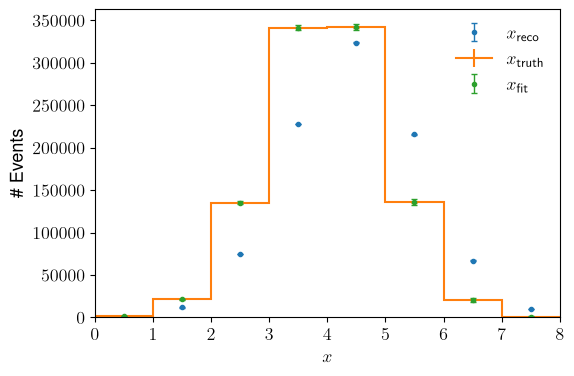

In [11]:
plot_values(
    values=[reco_values, truth_values, fit_values],
    labels=[reco_label, truth_label, r"$x_{\mathsf{fit}}$"],
    histtypes=["errorbar", "step", "errorbar"],
    edges=edges,
    xlabel="$x$",
)

In [12]:
fit.m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 99.64                      │            Nfcn = 127852             │
│ EDM = 1.13e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name         │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu_0         │  1.31e3   │  0.14e3   │  -0.14e3   │   0.14e3   │    0    │         │       │
│ 1 │ mu_1         │  21.5e3   │   0.6e3   │   -0.6e3   │   0.6e3    │    0    │         │       │
│ 2 │ mu_2         │  135.3e3  │   1.6e3   │   -1.5e3   │   1.5e3    │    0    │         │       │
│ 3 │ mu_3         │  341.3e3  │   2.9e3   │   -2.8e3   │   2.7e3    │    0    │         │       │
│ 4 │ mu_4         │  342.1e3  │   3.7e3   │   -3.5e3   │   3.5e3    │    0    │         │       │
│ 5 │ mu_5         │  135.8e3  │   3.5e3   │   -3.3e3   │   3.3e3    │    0    │         │       │
│ 6 │ mu_6         │  20.9e3   │   2.5e3   │   -2.3e3   │   2.3e3    │    0    │         │       │
│ 7 │ mu_7         │   0.8e3   │   0.8e3   │   -0.8e3   │   0.8e3    │    0    │         │       │
│ 8 │ theta_eff_0  │     0     │     1     │     -1     │     1      │         │         │       │
│ 9 │ theta_eff_1  │     0     │     1     │     -1     │     1      │         │         │       │
│ 10│ theta_eff_2  │     0     │     1     │     -1     │     1      │         │         │       │
│ 11│ theta_eff_3  │     0     │     1     │     -1     │     1      │         │         │       │
│ 12│ theta_eff_4  │     0     │     1     │     -1     │     1      │         │         │       │
│ 13│ theta_eff_5  │     0     │     1     │     -1     │     1      │         │         │       │
│ 14│ theta_eff_6  │     0     │     1     │     -1     │     1      │         │         │       │
│ 15│ theta_eff_7  │     0     │     1     │     -1     │     1      │         │         │       │
│ 16│ theta_mig_0  │     0     │     1     │     -1     │     1      │         │         │       │
│ 17│ theta_mig_1  │     0     │     1     │     -1     │     1      │         │         │       │
│ 18│ theta_mig_2  │     0     │     1     │     -1     │     1      │         │         │       │
│ 19│ theta_mig_3  │     0     │     1     │     -1     │     1      │         │         │       │
│ 20│ theta_mig_4  │     0     │     1     │     -1     │     1      │         │         │       │
│ 21│ theta_mig_5  │     0     │     1     │     -1     │     1      │         │         │       │
│ 22│ theta_mig_6  │     0     │     1     │     -1     │     1      │         │         │       │
│ 23│ theta_mig_7  │     0     │     1     │     -1     │     1      │         │         │       │
│ 24│ theta_mig_8  │     0     │     1     │     -1     │     1      │         │         │       │
│ 25│ theta_mig_9  │     0     │     1     │     -1     │     1      │         │         │       │
│ 26│ theta_mig_10 │     0     │     1     │     -1     │     1      │         │         │       │
│ 27│ theta_mig_11 │     0     │     1     │     -1     │     1      │         │         │       │
│ 28│ theta_mig_12 